# Chapter 11 - Variational Autoencoders (VAEs)

An autoencoder is a network that copies its input through a narrow "bottleneck" — forcing it to learn a compact **latent representation**.

A **VAE** adds a twist: instead of encoding x to a single point, it encodes x to a *probability distribution* (mean + variance), and regularizes it toward a standard normal. Decoding a random sample from that distribution lets the model **generate new images** that look like the training set.

`VAE = Encoder + Reparameterization trick + KL regularizer + Decoder`.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers, models

print("Keras", keras.__version__, "| TF", tf.__version__)

Keras 3.15.1 | TF 2.21.0


## 1. Data: MNIST digits (small edit to keep runtime seconds)

In [2]:
from keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = x_train[..., None]
x_test = x_test[..., None]
print("train", x_train.shape, "test", x_test.shape)

train (60000, 28, 28, 1) test (10000, 28, 28, 1)


## 2. Latent space definition
We'll embed into a 2-D latent space *only to be able to plot it*. Production VAEs use 8-128 dims.

In [3]:
latent_dim = 2

## 3. Encoder: image -> mean & log-variance
A VAE encoder outputs *two* vectors: mu (mean) and log_var (log-variance, kept in log space for numerical stability).

In [4]:
def build_encoder(input_shape, latent_dim):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(inputs)
    x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    return models.Model(inputs, (z_mean, z_log_var), name="encoder")

encoder = build_encoder((28, 28, 1), latent_dim)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

## 4. The reparameterization trick
"Sample z ~ N(mu, var)" is not differentiable w.r.t. mu/var. Trick: sample epsilon ~ N(0,1) and compute `z = mu + exp(log_var*0.5) * epsilon` — differentiability flows through mu & var.

In [5]:
class SamplingLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(z_log_var * 0.5) * epsilon

## 5. Decoder: latent -> image

In [6]:
def build_decoder(latent_dim):
    lz = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7*7*32, activation="relu")(lz)
    x = layers.Reshape((7, 7, 32))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)
    return models.Model(lz, outputs, name="decoder")

decoder = build_decoder(latent_dim)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1568)           │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,953 (163.88 KB)

 Trainable params: 41,953 (163.88 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train (compile with custom VAE loss)

In [7]:
from keras import models

class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, x):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x, training=True)
            z = SamplingLayer()([z_mean, z_log_var])
            reconstruction = self.decoder(z, training=True)
            mse = tf.reduce_mean(tf.square(x - reconstruction))
            # KL divergence to N(0,1)
            kl = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            loss = mse + kl * 0.5
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss, "mse": mse, "kl": kl}

    def call(self, x, training=None):
        z_m, z_lv = self.encoder(x)
        z = SamplingLayer()([z_m, z_lv])
        return self.decoder(z)

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
vae.fit(x_train, epochs=10, batch_size=128, verbose=1)

Epoch 1/10


  1/469 ━━━━━━━━━━━━━━━━━━━━ 17:11 2s/step - kl: 0.0013 - loss: 0.2310 - mse: 0.2304

  4/469 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - kl: 3.9571e-04 - loss: 0.2252 - mse: 0.2250

  6/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - kl: 8.3362e-05 - loss: 0.2191 - mse: 0.2191

  8/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - kl: 4.8396e-05 - loss: 0.2111 - mse: 0.2111

...

461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - kl: 1.4901e-08 - loss: 0.0654 - mse: 0.0654

463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - kl: -0.0000e+00 - loss: 0.0698 - mse: 0.0698

465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - kl: 1.4901e-08 - loss: 0.0674 - mse: 0.0674 

467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - kl: 1.4901e-08 - loss: 0.0633 - mse: 0.0633

469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl: 2.9802e-08 - loss: 0.0689 - mse: 0.0689


## 7. Generate: sample z from N(0,1) and decode!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


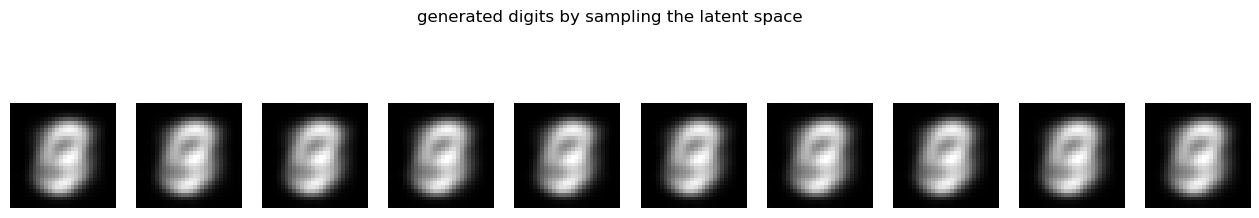

In [8]:
z_sample = np.random.normal(size=(10, latent_dim)).astype("float32")
imgs = decoder.predict(z_sample)
fig, axes = plt.subplots(1, 10, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i, :, :, 0], cmap="gray"); ax.axis("off")
plt.suptitle("generated digits by sampling the latent space"); plt.show()

## 8. Latent space interpolation (morph between two digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


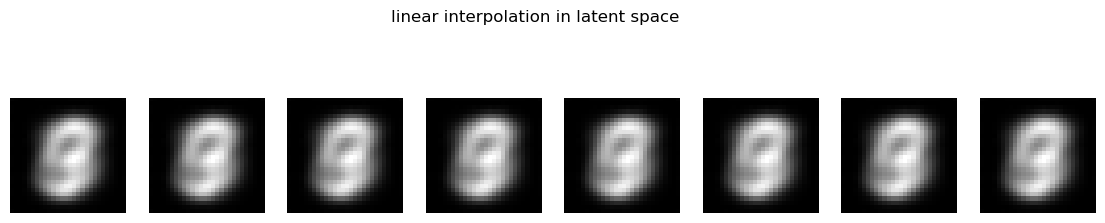

In [9]:
# pick two real test images, get their latent codes, sweep between them
def latent_of(img):
    m, _ = encoder.predict(img[None][..., None])
    return m

a = latent_of(x_test[0]); b = latent_of(x_test[9])
alphas = np.linspace(0, 1, 8)
fig, axes = plt.subplots(1, 8, figsize=(14, 3))
for j, al in enumerate(alphas):
    z = (1-al)*a + al*b
    img = decoder.predict(z.reshape(1, latent_dim))
    axes[j].imshow(img[0, :, :, 0], cmap="gray"); axes[j].axis("off")
plt.suptitle("linear interpolation in latent space"); plt.show()

## Recap
- VAE learns a smooth, continuous latent space => *generative* model.
- `reparameterization` makes sampling differentiable, so standard backprop works.
- The KL term enforces a standard-normal prior, making the space evenly populated.